(data-science:matplotlib)=
# Analyzing data with `pandas` and and `matplotlib`

Visualization in an essential part of scientific programming. Being able to communicate scientific results in way that is understandable for a broader community is an art that requires a lot of thoughts into what types of visual representation of the data you want to use.

A very good recent example is the *Summary for policy makers* report from the Intergovernmental Panel on Climate Change that was published in 2021. Below is a figure taken from the report which explains how the global surface temperature has changes the last years

```{figure} ../../figures/fn_klima.png
---
width: 700px
name: fn_klima
alt: fn_klima
---
Figure 1 from [Summary for Policymakers](https://www.ipcc.ch/report/ar6/wg1/downloads/report/IPCC_AR6_WGI_SPM_final.pdf) written by the Intergovernmental Panel on Climate Change.
```
A very important point when making scientific visualizations is to communicate to your audience the message in the results, and at the same time create visualizations that objectively displays the results. There are [several examples](https://www.nrk.no/norge/venstre-dempet-skrytegrafen-om-klimakutt-etter-massiv-kritikk-1.14768128) where visualizations are used in ways that makes people get the wrong impression.

While there are several ethical concerns when presenting scientific results, having the skills to create nice looking visualizations is a pre-requisite. In this section we will therefore focus on how you can create and style figures using `matplotlib` which is probably the most used library for visualizing simple graphs. To install `matplotlib` you can either use `pip`
```
pip install matplotlib
```
or `conda`
```
conda install -y matplotlib
```

## Getting a dataset for testing
To make the exercise of visualizing data a bit more interesting, we use a real world example, in particular we will use a public dataset about COVID19 in Norway which is available at <https://github.com/thohan88/covid19-nor-data>. This repository is regularly updated, but for the sake of reproducibility we will use data from a particular time stamp dating back to November 2021. To download the table with infected people we can use the following code snippet

In [1]:
path = "infected.csv"
url = "https://raw.githubusercontent.com/thohan88/covid19-nor-data/37b6b32d32db05b08dda15f002dcc2198836d4c1/data/01_infected/msis/municipality_wide.csv"

# Download data
import urllib.request
urllib.request.urlretrieve(url, path)

('infected.csv', <http.client.HTTPMessage at 0x7f688c1100d0>)

This will save the data to a file called `infected.csv`.

## Basic operations with `pandas`
We can load file we just downloaded with another popular data science library called `pandas`.

Again, to install `pandas` you can either use `pip`
```
pip install pandas
```
or `conda`
```
conda install -y pandas
```


### Loading data into a `pandas.DataFrame`
You should now be able to import pandas and load the content of the file into something called a pandas DataFrame

In [2]:
import pandas as pd
pd.set_option('display.max_columns', 7)  # This options is only for visualization in on the web
pd.set_option('display.max_rows', 10)  # This options is only for visualization in on the web

df = pd.read_csv(path)

Note that similar to `numpy` which is usually imported as `np` it is common to import `pandas` as `pd` (just because programmers are lazy). Note that `df` is a `pandas.DataFrame`

In [3]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


You can display the first 10 rows usings the slice operator

In [4]:
df[:10]

,time,kommune_no,kommune_name,...,2021-11-07,2021-11-08,2021-11-09
0,04:00:00,301,Oslo,...,58658,58874,59165
1,04:00:00,1101,Eigersund,...,188,188,188
2,04:00:00,1103,Stavanger,...,4328,4352,4374
3,04:00:00,1106,Haugesund,...,1501,1511,1533
4,04:00:00,1108,Sandnes,...,1776,1794,1819
5,04:00:00,1111,Sokndal,...,18,18,18
6,04:00:00,1112,Lund,...,45,45,45
7,04:00:00,1114,Bjerkreim,...,37,37,37
8,04:00:00,1119,Hå,...,354,354,355
9,04:00:00,1120,Klepp,...,422,425,426


or using the `head` method.

In [5]:
df.head(10)

,time,kommune_no,kommune_name,...,2021-11-07,2021-11-08,2021-11-09
0,04:00:00,301,Oslo,...,58658,58874,59165
1,04:00:00,1101,Eigersund,...,188,188,188
2,04:00:00,1103,Stavanger,...,4328,4352,4374
3,04:00:00,1106,Haugesund,...,1501,1511,1533
4,04:00:00,1108,Sandnes,...,1776,1794,1819
5,04:00:00,1111,Sokndal,...,18,18,18
6,04:00:00,1112,Lund,...,45,45,45
7,04:00:00,1114,Bjerkreim,...,37,37,37
8,04:00:00,1119,Hå,...,354,354,355
9,04:00:00,1120,Klepp,...,422,425,426


## Selecting a few columns
We can select a single column by treating the DataFrame as a dictionary with keys being the columns names. For example, one column name in this DataFrame is `kommune_name` and we can extract this column as follows

In [6]:
kommune_name = df["kommune_name"]
kommune_name

0                Oslo
1           Eigersund
2           Stavanger
3           Haugesund
4             Sandnes
            ...      
353           Nesseby
354         Båtsfjord
355      Sør-Varanger
356          Svalbard
357    Ukjent Kommune
Name: kommune_name, Length: 358, dtype: object

Note however, that `kommune_name` is a not a `pandas.DataFrame` but a `pandas.Series`

In [7]:
print(type(kommune_name))

<class 'pandas.core.series.Series'>


In other words, each columns of a `pandas.DataFrame` is a `pandas.Series`.

We can also select several columns by passing in a list of columns names, e.g

In [8]:
kommune_pop = df[["kommune_name", "population"]]
kommune_pop

,kommune_name,population
0,Oslo,693494
1,Eigersund,14811
2,Stavanger,143574
3,Haugesund,37357
4,Sandnes,79537
...,...,...
353,Nesseby,926
354,Båtsfjord,2221
355,Sør-Varanger,10158
356,Svalbard,0


However, now `kommune_pop` is again a `pandas.DataFrame`

In [9]:
print(type(kommune_pop))

<class 'pandas.core.frame.DataFrame'>


### Plotting using the `pandas` API
`pandas.DataFrame` has a built-in method called `plot` for visualizing the data. This is very handy if you want to quickly show a visualization of the data. For example to plot the population in the first 30 municipalities as a bar plot we can do the following

<AxesSubplot: xlabel='kommune_name'>

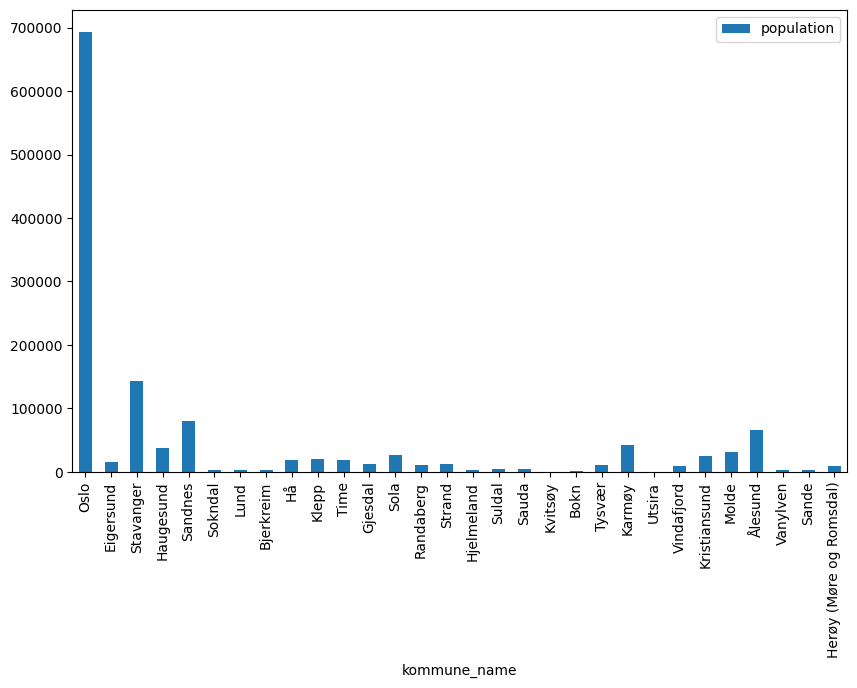

In [10]:
df[:30].plot(x="kommune_name", y="population", kind="bar", figsize=(10, 6))

You can check out the [`pandas` documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html) for more info about the `plot` method. While this is very nice to use for quick visualizations it has some limitations if you want to have full control over the visualization in which case you need to fall back to use `matplotlib` directly.

### Selecting a subset of the data based on some criterion
Very often when working with big dataset you would like to focus on a particular subset of the data that meets some requirements. One example in our case could be the we want to look at all the municipalities that are part of Viken fylke. The first approach you might try is to loop through all the rows and check wether the column `"fylke_name"` is equal to `"Viken"` and if it is, append it to some list, e.g

In [11]:
viken = pd.DataFrame([row for index, row in df.iterrows() if row["fylke_name"]=="Viken"])
viken

,time,kommune_no,kommune_name,...,2021-11-07,2021-11-08,2021-11-09
91,04:00:00,3001,Halden,...,1271,1273,1277
92,04:00:00,3002,Moss,...,2162,2178,2194
93,04:00:00,3003,Sarpsborg,...,3772,3780,3799
94,04:00:00,3004,Fredrikstad,...,4806,4826,4842
95,04:00:00,3005,Drammen,...,6140,6156,6202
...,...,...,...,...,...,...,...
137,04:00:00,3050,Flesberg,...,47,47,47
138,04:00:00,3051,Rollag,...,10,10,10
139,04:00:00,3052,Nore og Uvdal,...,18,18,18
140,04:00:00,3053,Jevnaker,...,204,204,207


However, there is a much more efficient way to do this. First we create a boolean Series as follows

In [12]:
df["fylke_name"] == "Viken"

0      False
1      False
2      False
3      False
4      False
       ...  
353    False
354    False
355    False
356    False
357    False
Name: fylke_name, Length: 358, dtype: bool

and then we evaluate the DataFrame at those entries that evaluations to `True`

In [13]:
viken = df[df["fylke_name"] == "Viken"]
viken

,time,kommune_no,kommune_name,...,2021-11-07,2021-11-08,2021-11-09
91,04:00:00,3001,Halden,...,1271,1273,1277
92,04:00:00,3002,Moss,...,2162,2178,2194
93,04:00:00,3003,Sarpsborg,...,3772,3780,3799
94,04:00:00,3004,Fredrikstad,...,4806,4826,4842
95,04:00:00,3005,Drammen,...,6140,6156,6202
...,...,...,...,...,...,...,...
137,04:00:00,3050,Flesberg,...,47,47,47
138,04:00:00,3051,Rollag,...,10,10,10
139,04:00:00,3052,Nore og Uvdal,...,18,18,18
140,04:00:00,3053,Jevnaker,...,204,204,207


Let us time the difference between the two approaches

In [14]:
%timeit -n 5 -r 10 pd.DataFrame([row for index, row in df.iterrows() if row["fylke_name"]=="Viken"])

52.6 ms ± 948 µs per loop (mean ± std. dev. of 10 runs, 5 loops each)


In [15]:
%timeit -n 5 -r 10 df[df["fylke_name"] == "Viken"]

665 µs ± 194 µs per loop (mean ± std. dev. of 10 runs, 5 loops each)


Note that this concept should be familiar if you have worked in `numpy` array before. Consider the follow `numpy` array

In [16]:
import numpy as np
np.random.seed(1)
x = np.random.randint(0, 20, size=20)
x

array([ 5, 11, 12,  8,  9, 11,  5, 15,  0, 16,  1, 12,  7, 13,  6, 18,  5,
       18, 11, 10])

and say that we would like to get all the values that are larger then 10. Then we could solve that with a list comprehension as follows

In [17]:
[xi for xi in x if xi > 10]

[11, 12, 11, 15, 16, 12, 13, 18, 18, 11]

However it would be much more efficient to do the following

In [18]:
x[x > 10]

array([11, 12, 11, 15, 16, 12, 13, 18, 18, 11])

The reason is that both `numpy` and `pandas` perform these operations in `C` which is much more efficient than list comprehensions which are pure python.

For completeness, let us also time the numpy operations

In [19]:
%timeit -n 10 -r 1000 [xi for xi in x if xi > 10]

The slowest run took 23.29 times longer than the fastest. This could mean that an intermediate result is being cached.
3.79 µs ± 3.15 µs per loop (mean ± std. dev. of 1000 runs, 10 loops each)


In [20]:
%timeit -n 10 -r 1000  x[x > 10]

The slowest run took 49.18 times longer than the fastest. This could mean that an intermediate result is being cached.
2.26 µs ± 3.3 µs per loop (mean ± std. dev. of 1000 runs, 10 loops each)


Let us look at the data for Oslo

In [21]:
oslo = df[df['fylke_name'] == "Oslo"]
oslo

,time,kommune_no,kommune_name,...,2021-11-07,2021-11-08,2021-11-09
0,04:00:00,301,Oslo,...,58658,58874,59165


### Extracting the data of the number of infected in Oslo and Norway
Now the first 6 values in each rows are information about the municipality

In [22]:
oslo.keys()[:10]

Index(['time', 'kommune_no', 'kommune_name', 'fylke_no', 'fylke_name',
       'population', '2020-03-26', '2020-03-27', '2020-03-28', '2020-03-29'],
      dtype='object')

The actual data of the registered infectious people starts at column 7 (index 6) where the name of the column is a date when the registration happen. We can pull out this data into a `numpy` array using the `.values` attribute

In [23]:
oslo_infected = oslo.values[0, 6:].astype(int)

Here the first dimension represents the rows (which is just one in our case), and the second row represents the columns (and we would like to extract all columns from index 6). Finally, we also make sure to convert the array to integers because the default behavior here is to use `object` as datatype which is far less efficient than working with integers.

Now we could of course do the same with the entire dataset which would have the shape

In [24]:
df.values.shape

(358, 599)

We could for example use this to get the number of infected in all of Norway by summing up all values along the columns (or the first axis at index 0). This can be done as follows

In [25]:
norway_infected = df.values[:, 6:].astype(int).sum(0)

## Plotting
We are now ready to start working with `matplotlib`. First thing we need to do is to import it. Although `matplotlib` is a big library containing a lot of functionality for plotting we will mainly be using the a subpackage called `pyplot`. This subpackage contains the main functionality to do basic plotting and it is common to import it as follows

In [26]:
import matplotlib.pyplot as plt

Let us first plot the data for Oslo and Norway in the same plot using `matplotlib`.

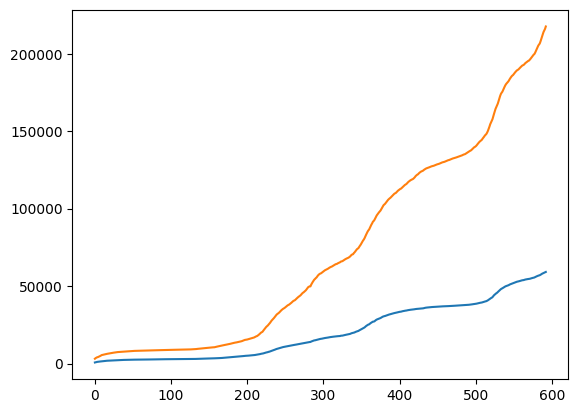

In [27]:
plt.plot(oslo_infected)
plt.plot(norway_infected)
plt.show()

We can also plot the number of new infected each day using `numpy.diff`. This will compute the difference between adjacent elements (if two adjacent elements are the same the difference is zero)

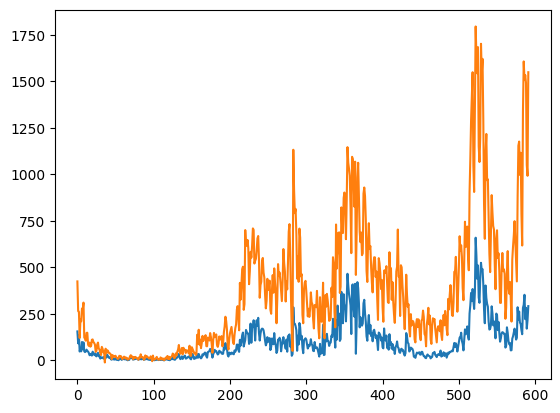

In [28]:
oslo_new_infected = np.diff(oslo_infected)
norway_new_infected = np.diff(norway_infected)
plt.plot(oslo_new_infected)
plt.plot(norway_new_infected)
plt.savefig("new_infected.png")
plt.show()

In both cases we used `plt.plot` to plot the lines. In the seconds plot we also used `plt.savefig` to save the figure. Using `plt` directly is OK if you want to do something quick and dirty. However, this is not the recommended way of programmatically create plots.

### The `matplotlib` object model
The recommended way to create a plot is by working with the the *figure* and the *axes*. In one figure we can have one or more axes, in which case we typically refer to each axes as a subplot. The plotting is performed on the axes while the figure is what we eventually save to disk.

Let us rewrite the example above using the object model

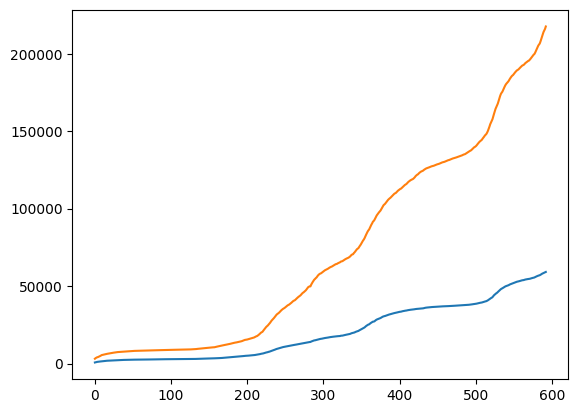

AxesSubplot(0.125,0.11;0.775x0.77)


In [29]:
fig, ax = plt.subplots()
ax.plot(oslo_infected)
ax.plot(norway_infected)
plt.show()
print(ax)

### Why you should use the object model
So you might be wondering what is the advantages in using the object model approach over working directly with `plt.`, i.e using

```python
fig, ax = plt.subplots()
ax.plot(norway_new_infected)
fig.savefig("new_infected.png")
```
instead of

```python
plt.plot(norway_new_infected)
plt.savefig("new_infected.png")
```
One obvious reason is if you are working with multiple figures at the same time, which you might do if you are plotting several things within a loop. Then we will have full control over what is plotted where and which figures contains which axes, e.g
```python
fig_new_infected, ax_new_infected = plt.subplots()
fig_total_infected, ax_total_infected = plt.subplots()

ax_new_infected.plot(norway_new_infected)
ax_total_infected.plot(norway_infected)

fig_new_infected.savefig("new_infected.png")
fig_total_infected.savefig("total_infected.png")
```
This would not be possible if you are using `plt.` directly.

What really happens when you call `plt.plot` is the following (see e.g [here](https://github.com/matplotlib/matplotlib/blob/v3.5.3/lib/matplotlib/pyplot.py#L2765-L2769))
```python
# from pyplot.plot:
def plot(*args, **kwargs):
    ax = gca()  # gca = get current axes
    ax.plot(*args, **kwargs)
```
This means that when you call `plt.plot` you are essentially calling `ax.plot` only `ax` will be the current axes (whatever that means).
The same goes with `plt.figure`, which can be summarized as follows
```python
# from pyplot.savefig
def savefig(*args, **kwargs):
    fig = gcf()  # gcf = get current figure
    fig.savefig(*args, **kwargs)
```

### Anatomy of a plot

There are several different objects in a plot. So far we have seen the *Figure*, which is the outer most object consisting of one or more *axes*, which are the object where we plot stuff.

At <https://matplotlib.org/_images/anatomy.png> they have a figure summarizing all the different objects that you will find in a plot, and how to access and change these objects.

```{figure} https://matplotlib.org/_images/anatomy.png
---
width: 100px
name: mpl_anatomy
alt: mpl_anatomy
---
Anatomy of a matplotlib plot: Summary of the main objects in a plot
```
- *Figure* is the outer most object in a plot and is the object that you ca save to a file or show using `plt.show()`
- *Axes* are the panels where you perform the plotting. If one figure has more than one axes we say that those axes form subplots.
- *Axis* (which should not be mistaken from axes) refer to the lower horizontal (x-axis) and left vertical (y-axis) parts in the plots.
- *Spines* refer to the four axis lines (left, right, bottom and top)
- *Ticks* refer to the small lines on the x- and y-axis that are orthogonal to the spines. There are two kinds for ticks; major and minor where the major ticks are longer than the minor ticks
- *Ticklabels* are text that explains the ticks
- *X- and Ylabels* a are text that explains the x- and y axis.
- *Grid* are the slightly less highlighted horizontal and vertical lines that are typically drawn at each major tick.
* *Lines* are objects that are plotted
* *Legend* refer to the collection of labels for each line (or plotted object)
* *Title* is a text that contains a description of a given axes.

### Creating subplots
When we use `plt.subplots` it also very easy to make subplots, e.g

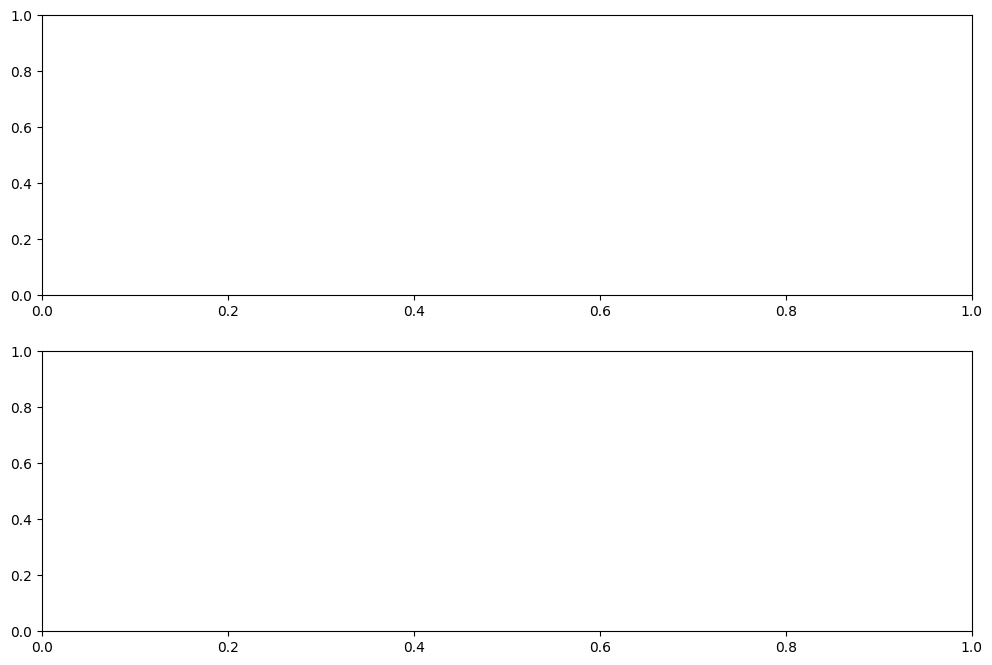

In [30]:
fig, axs = plt.subplots(2, 1, figsize=(12, 8))

We can also see that `axs` now is a `numpy` array or length 2

In [31]:
print(axs)
print(type(axs))
print(axs.shape)

[<AxesSubplot: > <AxesSubplot: >]
<class 'numpy.ndarray'>
(2,)


and the figures is, well, a Figure

In [32]:
print(fig)

Figure(1200x800)


We could also make a 2 by 2 subplot

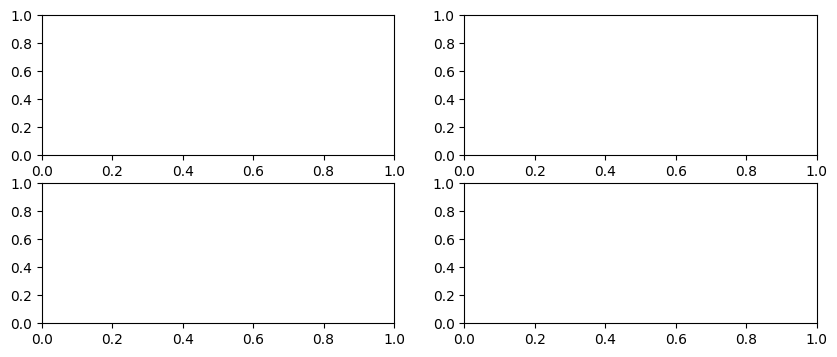

In [33]:
fig, axs = plt.subplots(2, 2, figsize=(10, 4))

in which case `axs` would be a 2 by 2 numpy array

In [34]:
print(axs)
print(axs.shape)

[[<AxesSubplot: > <AxesSubplot: >]
 [<AxesSubplot: > <AxesSubplot: >]]
(2, 2)


### Plotting on different axes
Now that we have seen how to make subplots let us try to create a figure with two different subplots. Let us create two axes and plot the total number of infected on the first one and the total number of newly infected on the second axes

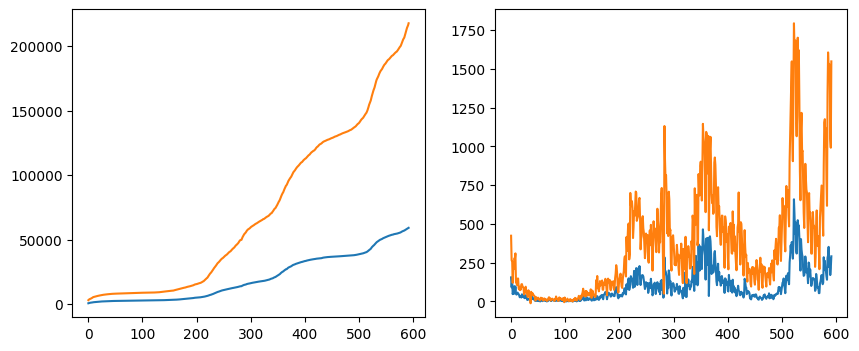

In [35]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].plot(oslo_infected)
axs[0].plot(norway_infected)

axs[1].plot(oslo_new_infected)
axs[1].plot(norway_new_infected)
plt.show()

We can also change the layout so that instead of having the first plot to the left and the second do the right we can have, the first is on top of the second by changing the the first two arguments to `plt.subplots`.

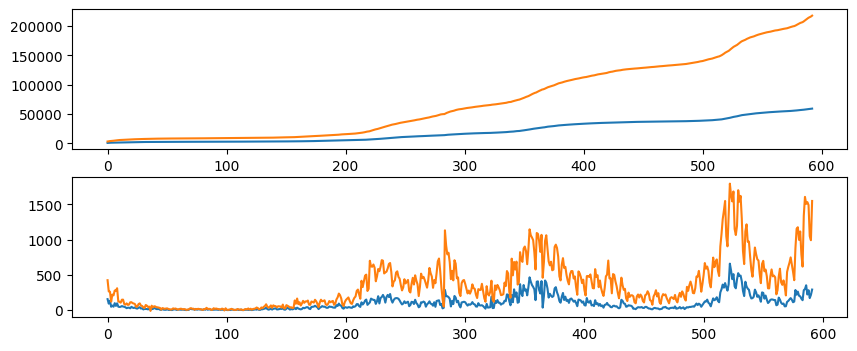

In [36]:
fig, axs = plt.subplots(2, 1, figsize=(10, 4))
axs[0].plot(oslo_infected)
axs[0].plot(norway_infected)

axs[1].plot(oslo_new_infected)
axs[1].plot(norway_new_infected)
plt.show()

or using keyword arguments

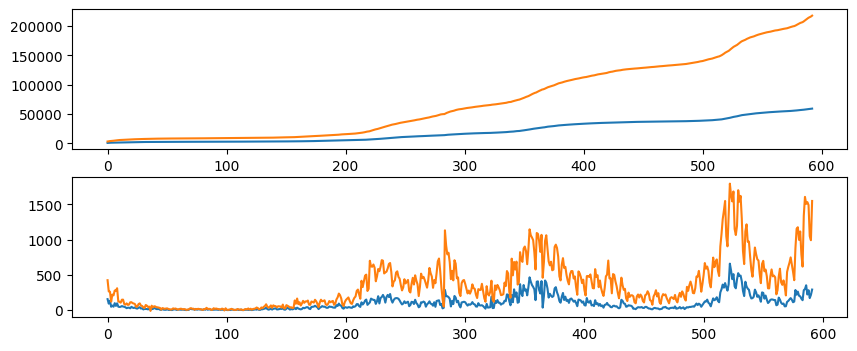

In [37]:
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(10, 4))
axs[0].plot(oslo_infected)
axs[0].plot(norway_infected)

axs[1].plot(oslo_new_infected)
axs[1].plot(norway_new_infected)
plt.show()

### Sharing axis
When we plot the total infected and the total new infected, the x-axis are the same, i.e the number of days since first the first day registered. We will see later how we can turn these values into dates, but the first thing we can to is to share the axis between the two subplots by passing in the `sharex=True` to `plt.subplots`

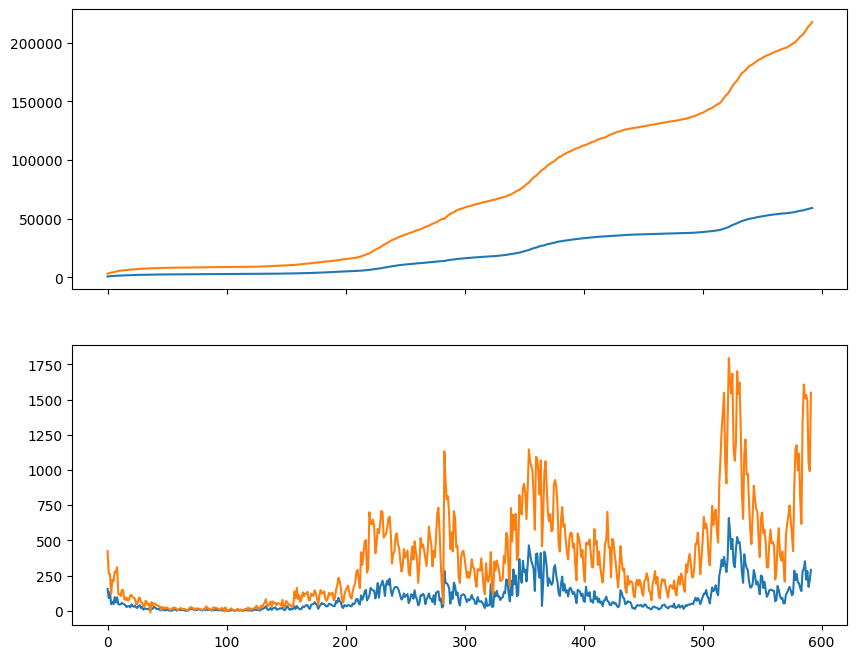

In [38]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
axs[0].plot(oslo_infected)
axs[0].plot(norway_infected)

axs[1].plot(oslo_new_infected)
axs[1].plot(norway_new_infected)
plt.show()

Now, we could also share the $y$-axis between the subplots by passing in `sharey=True` as well, although in this specific case the two plots have very different scales so it might not be preferable

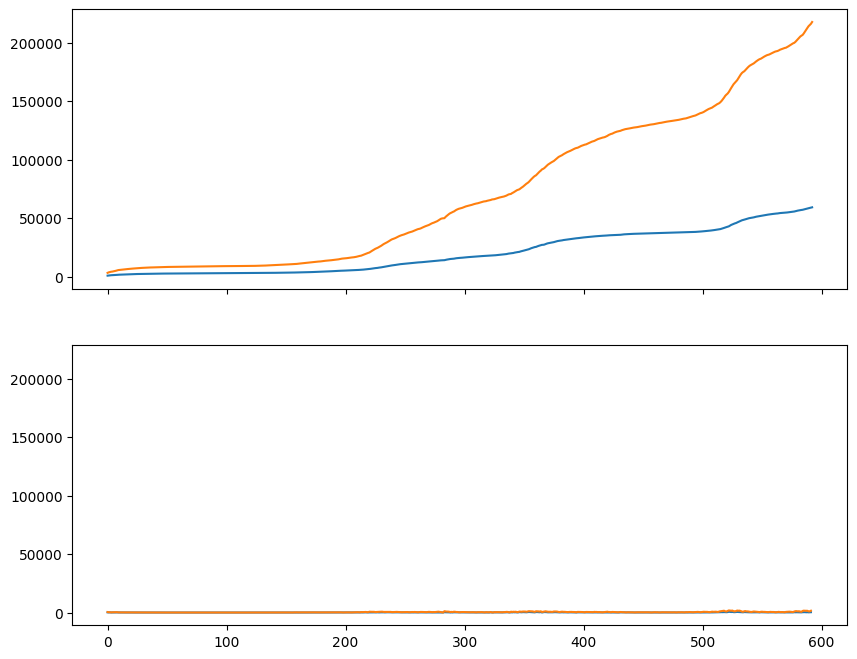

In [39]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True, sharey=True)
axs[0].plot(oslo_infected)
axs[0].plot(norway_infected)

axs[1].plot(oslo_new_infected)
axs[1].plot(norway_new_infected)
plt.show()

### Legends

The simplest way to add a legend to a plot is by sending in the labels to each plot and call `ax.legend`

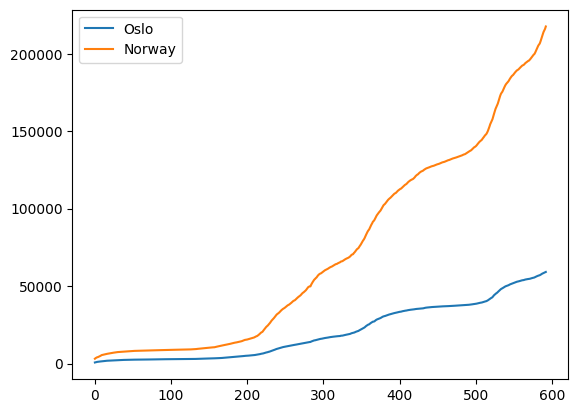

In [40]:
fig, ax = plt.subplots()
ax.plot(oslo_infected, label="Oslo")
ax.plot(norway_infected, label="Norway")
ax.legend()
plt.show()

Another way to create a legend is to keep track of the lines and pass in the lines (also referred to as handles) together with the labels into `ax.legend`

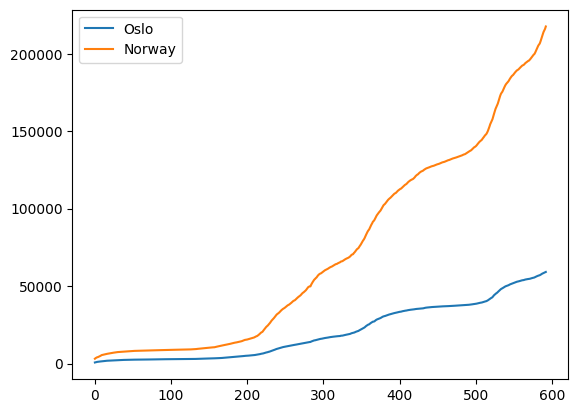

In [41]:
fig, ax = plt.subplots()
l1, = ax.plot(oslo_infected)
l2, = ax.plot(norway_infected)
ax.legend((l1, l2), ("Oslo", "Norway"))
plt.show()

Note the we write `l1, = ax.plot(oslo_infected)`. This is because `ax.plot` returns a list of lines and in this case the list returns only one element which we can unpack by adding a comma (`,`). Another approach would be to only pass in the the first element from list of lines

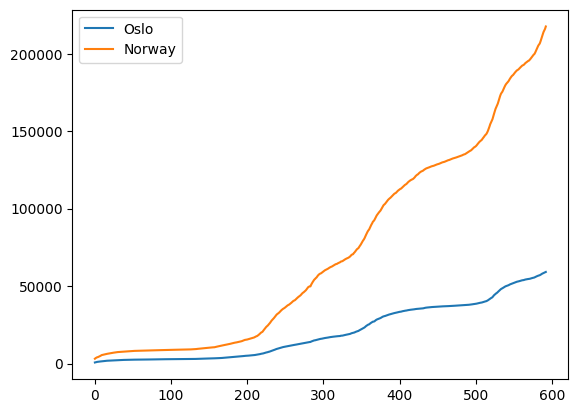

In [42]:
fig, ax = plt.subplots()
l1 = ax.plot(oslo_infected)
l2 = ax.plot(norway_infected)
ax.legend((l1[0], l2[0]), ("Oslo", "Norway"))
plt.show()

#### Placing the legend

If you want to place your legend in a different location you can pass in the `loc` argument, e.g

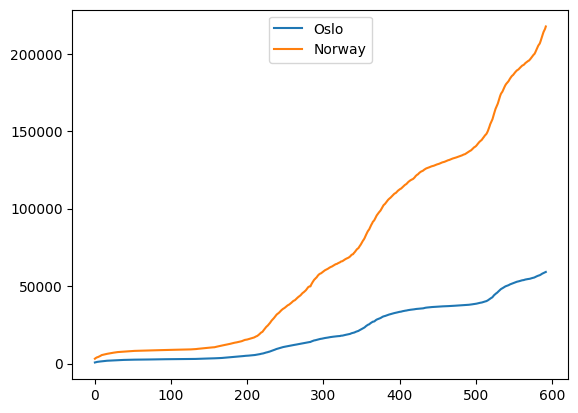

In [43]:
fig, ax = plt.subplots()
ax.plot(oslo_infected, label="Oslo")
ax.plot(norway_infected, label="Norway")
ax.legend(loc="upper center")
plt.show()

In this case `loc` was set to `"upper center"` which will place the legend in the upper center of the figure.

By default `loc="best"` in which case `matplotlib` will do its best to position the legend so that the legend has the minimum overlap with other objects in the figure.

One thing you might consider is to place the legend outside of the the plot. This is most easily done by combining `loc` with `bbox_to_anchor`. In this case `loc` will no longer refer to the figure, but to the legend itself, while `bbox_to_anchor` will refer to the location on figure where `(0, 0)` refers to the lower left corner `(0, 1)` will refer to the upper left corner and so on. For example `loc="upper left"` combined with `bbox_to_anchor=(0, 1)` will
place the upper left corner of the legend in in the upper left corner of the figure.

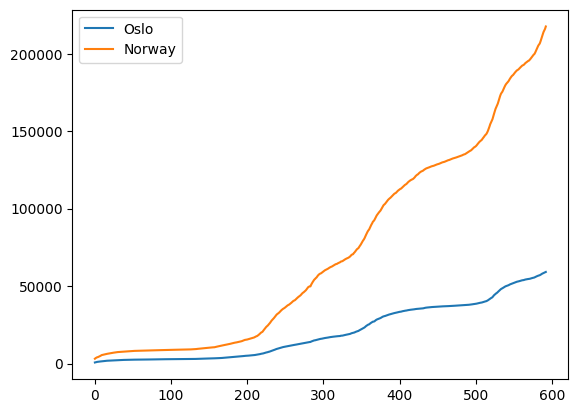

In [44]:
fig, ax = plt.subplots()
ax.plot(oslo_infected, label="Oslo")
ax.plot(norway_infected, label="Norway")
ax.legend(bbox_to_anchor=(0, 1), loc='upper left')
plt.show()

These things are more easily learned by trying different values of `loc` and `bbox_to_anchor` and see what happens.

#### Legends for subplots
If you are working with multiple subplots then one option is to create a separate legend for each subplot in the same way as we did for a single plot

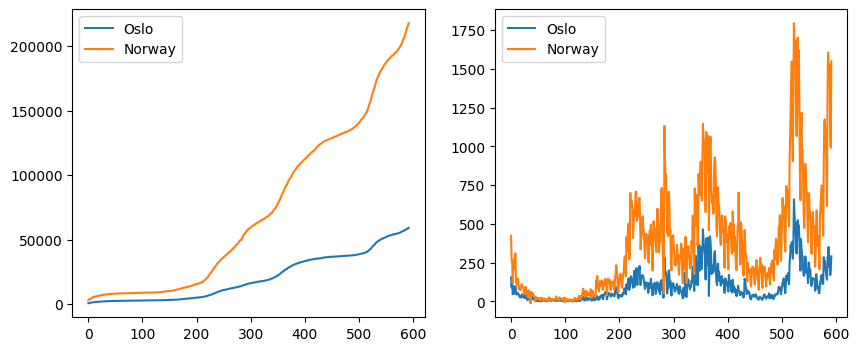

In [45]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].plot(oslo_infected, label="Oslo")
axs[0].plot(norway_infected, label="Norway")

axs[1].plot(oslo_new_infected, label="Oslo")
axs[1].plot(norway_new_infected, label="Norway")

for ax in axs:
    ax.legend()
plt.show()

However, this might not be what you want. In out case we are basically repeating the same legend in both subplots, so finding a way to make a combined legend would be preferable. Now one way to do this is to just add a legend to the second axes, e.g

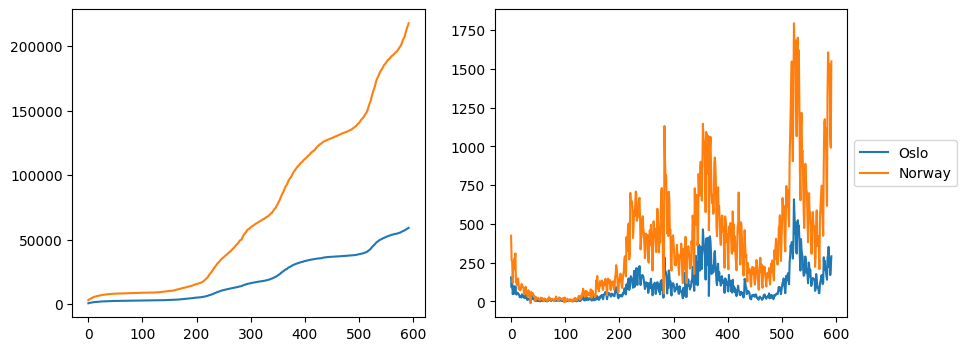

In [46]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].plot(oslo_infected, label="Oslo")
axs[0].plot(norway_infected, label="Norway")

axs[1].plot(oslo_new_infected, label="Oslo")
axs[1].plot(norway_new_infected, label="Norway")

axs[1].legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.show()

However, in this case you might end up a situation where parts of the legend ends up outside of the figure if you try to save it

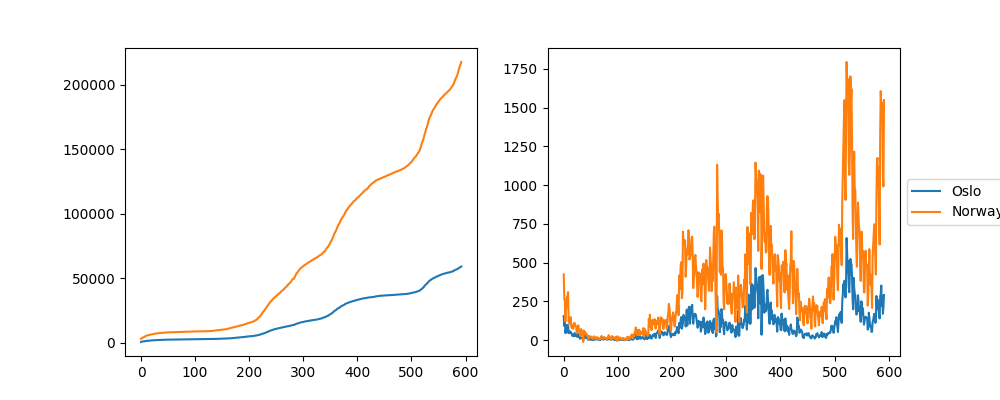

In [47]:
fig.savefig("subplots_legend1.png")
from IPython import display
display.Image("subplots_legend1.png")

To fix this you can pass in `bbox_inches="tight"` to `fig.savefig`

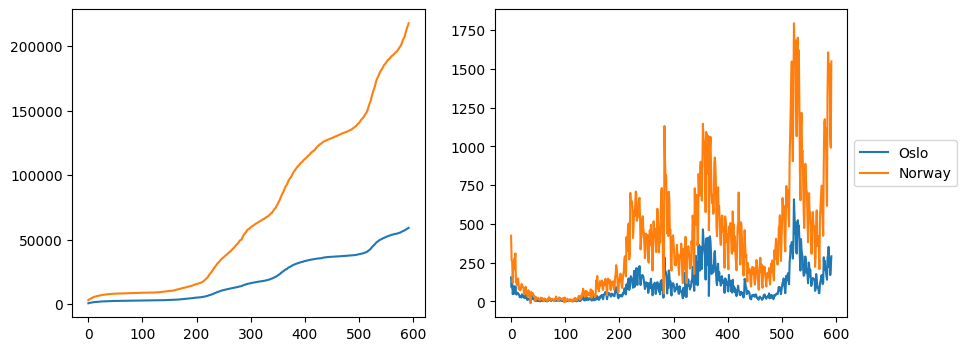

In [48]:
fig.savefig("subplots_legend2.png", bbox_inches="tight")
from IPython import display
display.Image("subplots_legend2.png")

Another way that doesn't suffer from the same problems with saving is to add the legend to the figure instead of one of the axes

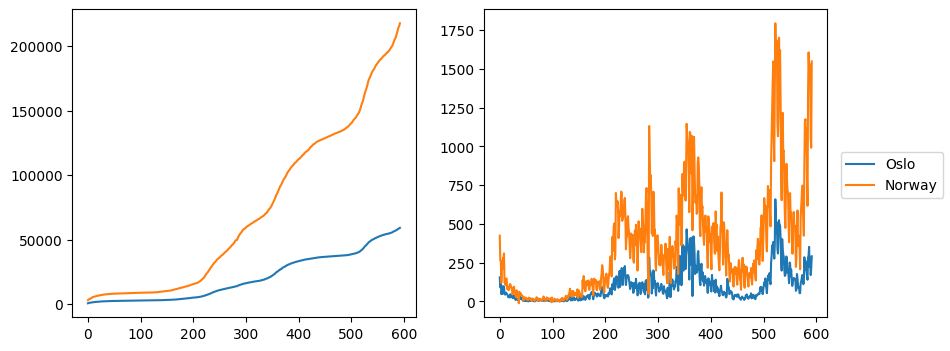

In [49]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
l1, = axs[0].plot(oslo_infected, color="tab:blue")
l2, = axs[0].plot(norway_infected, color="tab:orange")

axs[1].plot(oslo_new_infected, color="tab:blue")
axs[1].plot(norway_new_infected, color="tab:orange")

fig.subplots_adjust(right=0.88)
fig.legend((l1, l2), ("Oslo", "Norway"), loc='center right')
plt.show()

In this case we first make sure to select the same color for both subplots, and extract the lines from one of the subplots that is passed on to `fig.legend` together with the labels. Finally we use `fig.adjust_subplots` to rescale the subplots so the the legend fit.

### Adding a grid

Adding a grid makes it easier to link the lines to the axis and we can easily add one using `ax.grid`

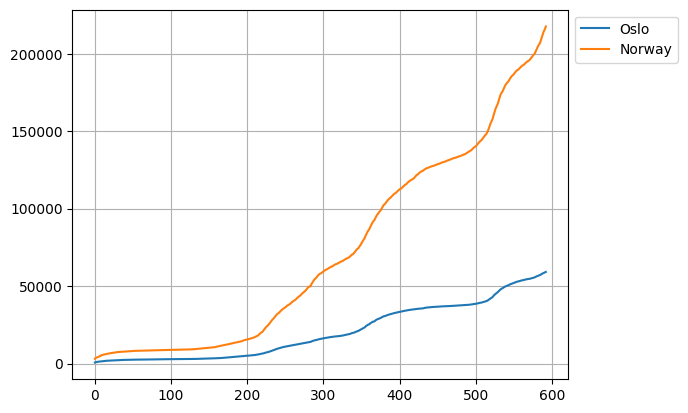

In [50]:
fig, ax = plt.subplots()
ax.plot(oslo_infected, label="Oslo")
ax.plot(norway_infected, label="Norway")
ax.grid()
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

### Adding a title

A title can be added using `ax.set_title`

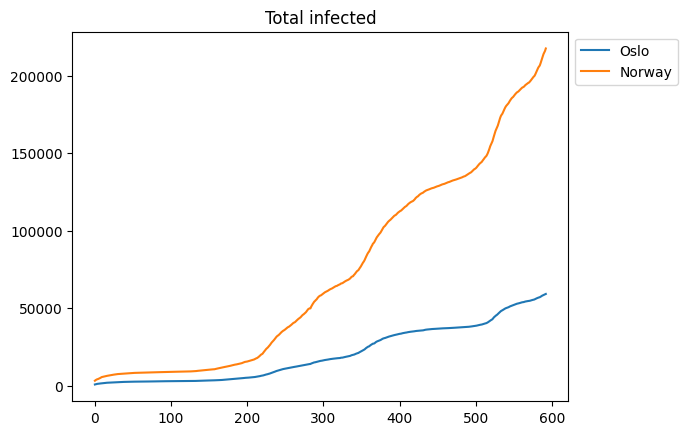

In [51]:
fig, ax = plt.subplots()
ax.plot(oslo_infected, label="Oslo")
ax.plot(norway_infected, label="Norway")
ax.set_title("Total infected")
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

### X- and Ylabels
We can add labels to the $x$- and $y$-axis using the `ax.set_xlabel` and `ax.set_ylabel` respectively

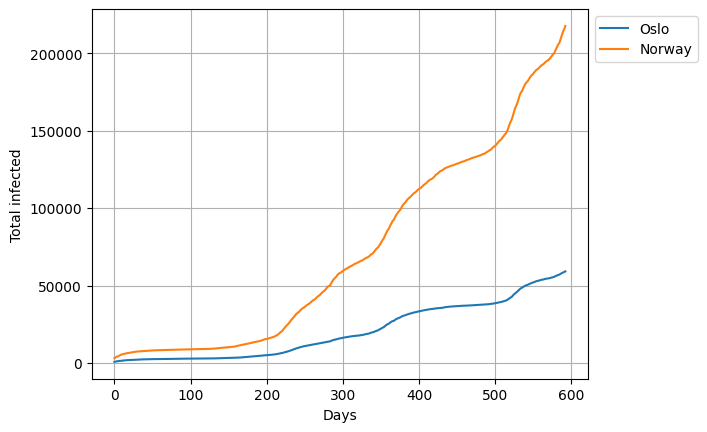

In [52]:
fig, ax = plt.subplots()
ax.plot(oslo_infected, label="Oslo")
ax.plot(norway_infected, label="Norway")
ax.grid()
ax.set_xlabel("Days")
ax.set_ylabel("Total infected")
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

### Ticks and Ticklabels

Now we will see how we can change the ticks in the plot. The ticks are markers that can be used to label specific points on the $x$- and $y$-axis as well as the grid lines. To change the ticks on the $x$-axis you can use `ax.set_xticks`

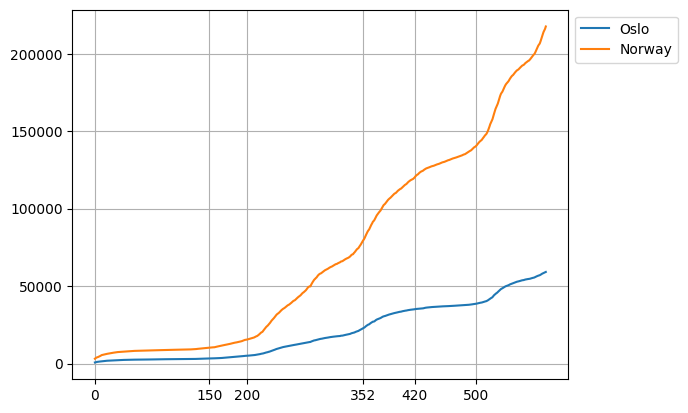

In [53]:
fig, ax = plt.subplots()
x = np.arange(len(oslo_infected))
ax.plot(x, oslo_infected, label="Oslo")
ax.plot(x, norway_infected, label="Norway")
ax.grid()
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
ax.set_xticks([0, 150, 200, 352, 420, 500])
plt.show()

and there is an equivalent method for the $y$-axis

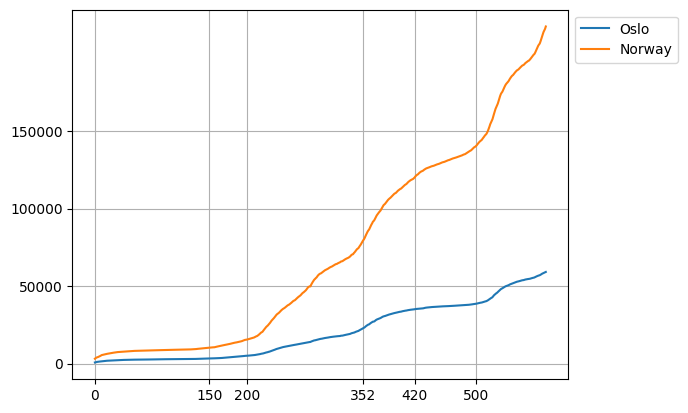

In [54]:
fig, ax = plt.subplots()
x = np.arange(len(oslo_infected))
ax.plot(x, oslo_infected, label="Oslo")
ax.plot(x, norway_infected, label="Norway")
ax.grid()
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
ax.set_yticks([0, 50_000, 100_000, 150_000])
ax.set_xticks([0, 150, 200, 352, 420, 500])
plt.show()

It is common to combine `ax.set_xticks` with `ax.set_xticklabels` in order to change the labels as the different tick points

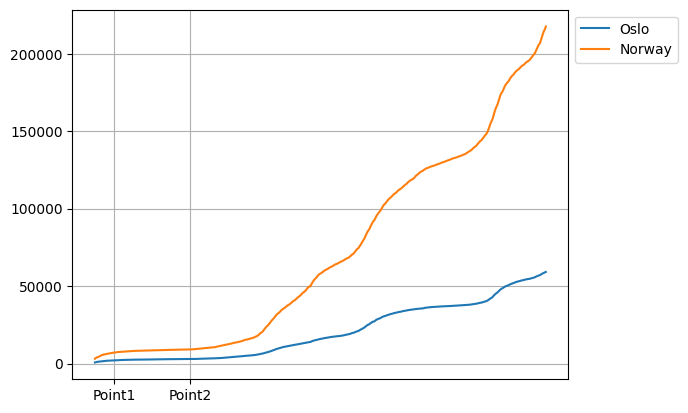

In [55]:
fig, ax = plt.subplots()
x = np.arange(50, len(oslo_infected)+50)
ax.plot(x, oslo_infected, label="Oslo")
ax.plot(x, norway_infected, label="Norway")
ax.grid()
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
ax.set_xticks([75, 175])
ax.set_xticklabels(["Point1", "Point2"])
plt.show()

#### Changing the ticklabels from points to dates

Now that we have learned the basics of ticks and ticklabels, we would like to use this knowledge change the ticklabels from points since first day of registration to dates. The dates are stored as column names in the original data frame starting at index 6

In [56]:
dates = df.keys().to_numpy()[6:]
print(dates[:10])  # printing the first 10 dates

['2020-03-26' '2020-03-27' '2020-03-28' '2020-03-29' '2020-03-30'
 '2020-03-31' '2020-04-01' '2020-04-02' '2020-04-03' '2020-04-04']


Here we also convert the keys to a `numpy` array using the method `.to_numpy`. Now say that we want to have 6 ticks on the $x$ axis with 6 equally spaced dates. One way we could do this is to first find the indices of the dates by creating a linearly spaced array of 6 values starting a zero and ending at the length of the `dates` array. We can do this using `np.linspace`. This will be our xticks

In [57]:
xticks = np.linspace(0, len(oslo_infected)-1, 6).astype(int)

We also need to convert these values to integers so that we can get the xticklabels

In [58]:
xticklabels = dates[xticks]

Now, the rest should be easy

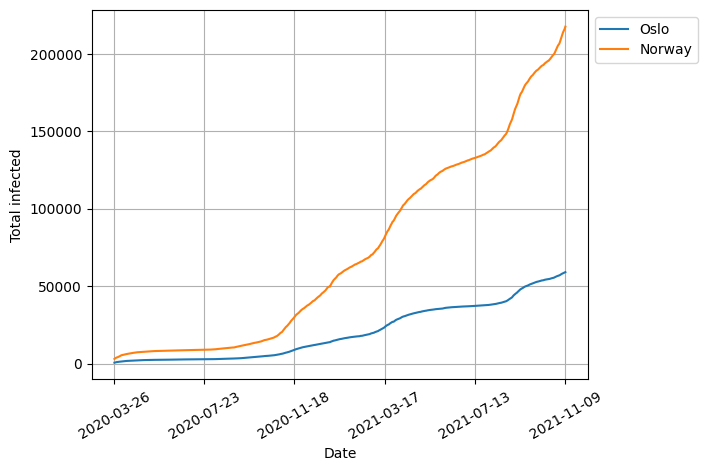

In [59]:
fig, ax = plt.subplots()
x = np.arange(len(oslo_infected))
ax.plot(x, oslo_infected, label="Oslo")
ax.plot(x, norway_infected, label="Norway")
ax.grid()
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, rotation=30)
ax.set_xlabel("Date")
ax.set_ylabel("Total infected")
plt.show()

Here we also added a 30 degree rotation to the ticklabels so that they don't overlap.

#### Changing ticklabels on subplots
We are now at a point where we can do some pretty advanced configurations on out plots. Let us try to take it to the next level. Now we would like to add custom ticks represented by the dates to the two subplots, and we would also like to share the x-axis and now lets try to add the legend to the center of the plot.

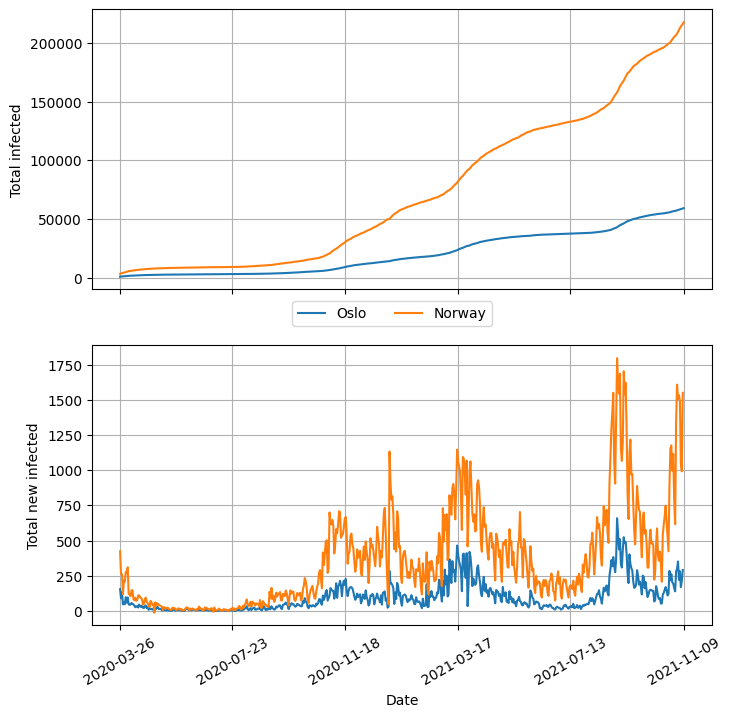

In [60]:
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 8))
l1, = axs[0].plot(x, oslo_infected)
l2, = axs[0].plot(x, norway_infected)
axs[0].set_ylabel("Total infected")

axs[1].plot(x[:-1], oslo_new_infected)
axs[1].plot(x[:-1], norway_new_infected)
axs[1].set_ylabel("Total new infected")

for ax in axs:
    ax.grid()
    ax.set_xticks(xticks)

# We only add the labels to the bottom axes
axs[1].set_xticklabels(xticklabels, rotation=30)
axs[1].set_xlabel("Date")

fig.legend((l1, l2), ("Oslo", "Norway"), bbox_to_anchor=(0.5, 0.5), loc='center', ncol=2)
plt.show()

### Choosing a different style

So far we have worked the default fonts and styles from `matplotlib` but there of course a large list of different styles that can be applied. You can list the available ones using `plt.style.available`

In [61]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


We can switch the style using `plt.style.use`

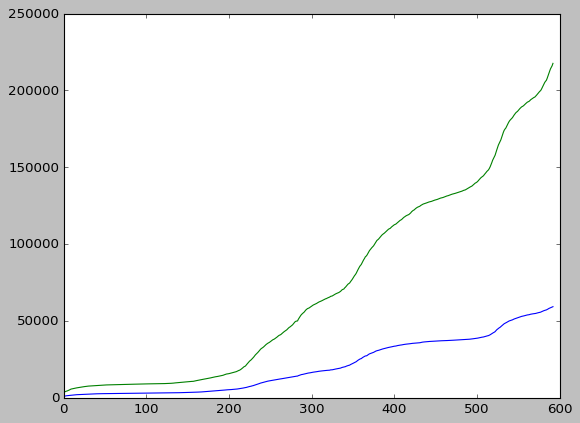

In [62]:
plt.style.use('classic')
fig, ax = plt.subplots()
ax.plot(oslo_infected)
ax.plot(norway_infected)
plt.show()

Now any plot produced during this session will from now on use this style unless you switch to another one. So let us change back to the default style

In [63]:
plt.style.use('default')

It is also possible to only apply a style withing a given context. This can be achieved using a context manager (or a `with`-block).

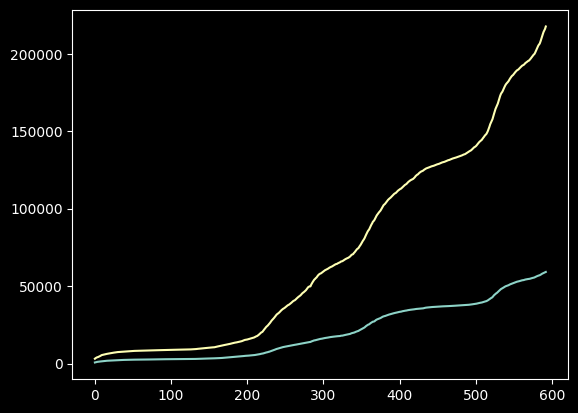

In [64]:
with plt.style.context("dark_background"):
    # Style will only be applied within this block
    fig, ax = plt.subplots()
    ax.plot(oslo_infected)
    ax.plot(norway_infected)
    plt.show()

# Now we fall back to the default style again

Another funny style is the `XKCD` style

findfont: Font family 'xkcd' not found.


findfont: Font family 'xkcd Script' not found.


findfont: Font family 'Humor Sans' not found.


findfont: Font family 'Comic Neue' not found.


findfont: Font family 'Comic Sans MS' not found.


...

findfont: Font family 'xkcd' not found.


findfont: Font family 'xkcd Script' not found.


findfont: Font family 'Humor Sans' not found.


findfont: Font family 'Comic Neue' not found.


findfont: Font family 'Comic Sans MS' not found.


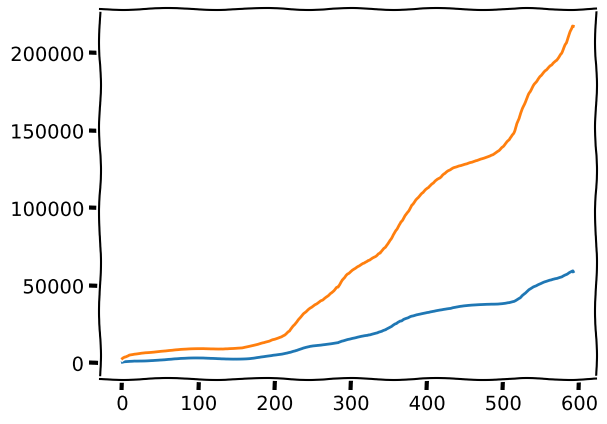

In [65]:
with plt.xkcd():
    fig, ax = plt.subplots()
    ax.plot(oslo_infected)
    ax.plot(norway_infected)
    plt.show()

### Styling lines
When you plot lines there are several different options for styling. You can change the `linestyle`, `color`, `marker`, `markersize` and `linewidth` just to name a few

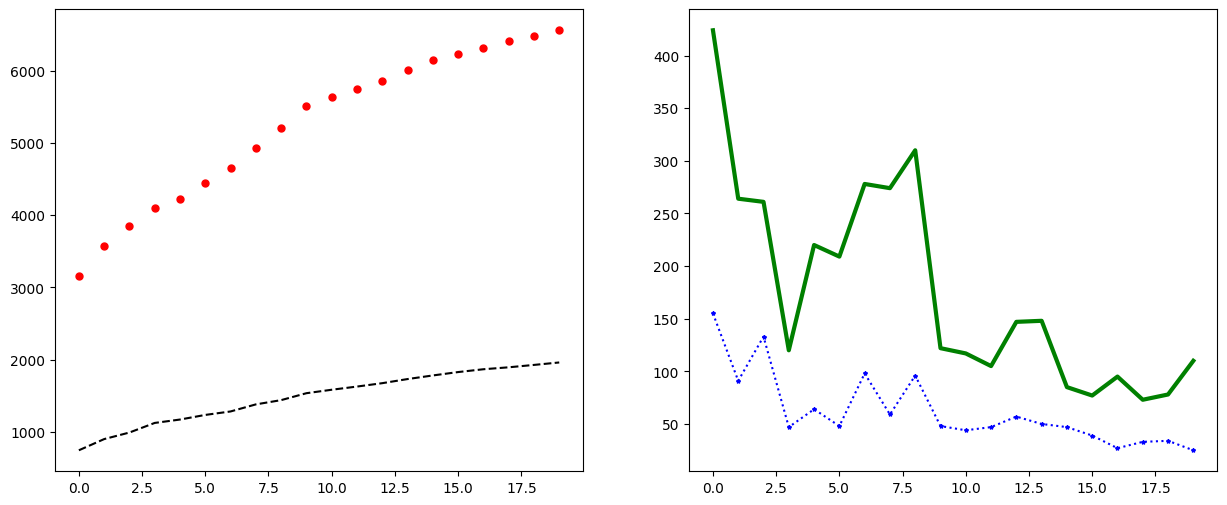

In [66]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6))
axs[0].plot(oslo_infected[:20], linestyle="--", color="k")
axs[0].plot(norway_infected[:20], linestyle="", marker=".", color="r", markersize=10)

axs[1].plot(oslo_new_infected[:20], linestyle=":", marker="*", markersize=3, color="b")
axs[1].plot(norway_new_infected[:20], linestyle="-", linewidth="3", color="g")
plt.show()

### Plotting many lines with different colors and markers
Now say that you want to plot the total number of infected in each municipality in Rogaland fylke.
```{code-block} python
rogaland = df[df["fylke_name"] == "Rogaland"]
```
However, this dataframe contains 23 rows

In [67]:
print(len(rogaland))

NameError: name 'rogaland' is not defined

which is will be quite difficult to visualize. One thing we can to is to specify the colors we would like to use, e.g

In [68]:
colors = ["r", "b", "g", "y", "c", "m"]

and some markers, e.g

In [69]:
markers = ["x", "v", "o", "<", "."]

and then we can use a method called `cycle` from the `itertools` library to just cycle through the colors and makers. For example if we have 8 values we would get the following combinations

In [70]:
from itertools import cycle
for i, color, marker in zip(range(8), cycle(colors), cycle(markers)):
    print(i, color, marker)

0 r x
1 b v
2 g o
3 y <
4 c .
5 m x
6 r v
7 b o


The `cycle` method will just go on forever continuing at the first element once it reaches the end of the list. This reason this `for` loop ends is because `zip` will stop when the first iterable is exhausted, which in this case will be `range(8)`.

Now let us plot the total number of infected within each municipality in Rogaland

NameError: name 'rogaland' is not defined

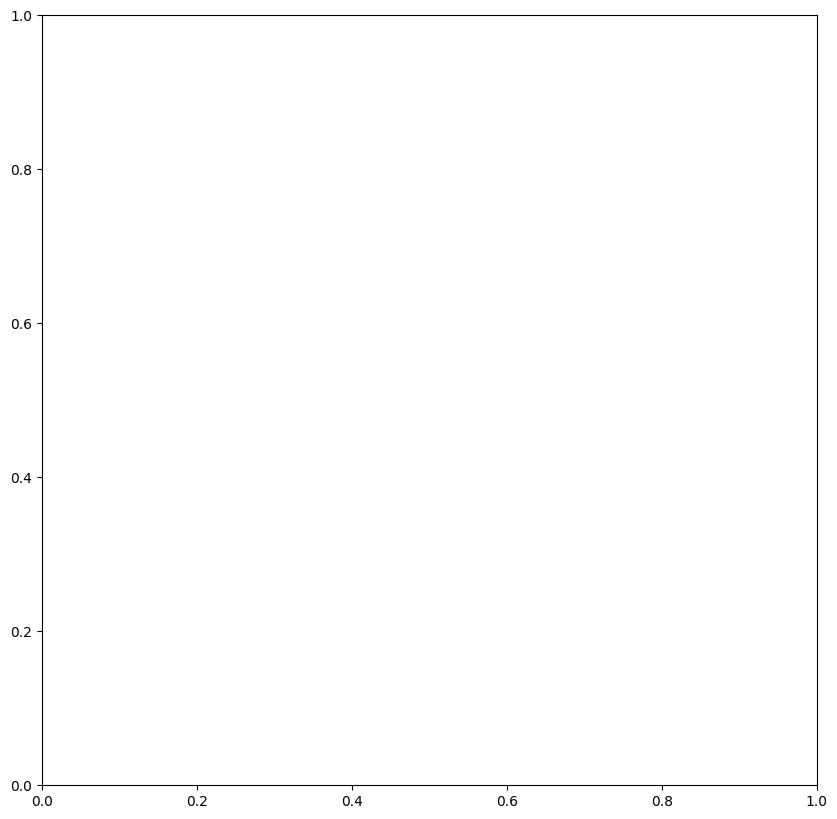

In [71]:
fig, ax = plt.subplots(figsize=(10, 10))
for x, marker, color in zip(rogaland.values, cycle(markers), cycle(colors)):
    name = x[2]  # Municipality name is at the second index
    v = x[6:]    # Data is from index 6 and onwards
    # Let ut plot every 20th value with the given marker and color
    # and give the name as a label
    ax.plot(v[::20], label=name, marker=marker, color=color)

# Also set a limit on the y-axis so that it is a bit easier to see
# the difference
ax.set_ylim((0, 500))
ax.legend()
plt.show()

### Color maps
There is a large list of available color maps in `matplotlib` (see <https://matplotlib.org/3.1.1/tutorials/colors/colormaps.html>) and selecting a good to


## Python's visualization landscape

## Resources
The [scientific visualization book](https://github.com/rougier/scientific-visualization-book) is a great resource if you want to learn more advanced features of matplotlib. Apart from that, <https://matplotlib.org> and <https://pandas.pydata.org> contains great documentation for `matplotlib` and `pandas` respectively.